# Privacy-Preserving Machine Learning: Matrix Masking on High-Resolution Data (Figshare MRI)

## 1. Specification of Dependencies & Data Setup
In accordance with NeurIPS guidelines for research code reproducibility, this section explicitly outlines the environment, dependencies, and datasets required to run this framework.

**Dependencies:**
* `torch`, `torchvision`, `scikit-learn`, `matplotlib`, `seaborn`, `pandas`, `kaggle`
* These can be installed via the inline pip command below. A CUDA-enabled GPU with sufficient VRAM (e.g., T4/G4) is strictly required to handle high-resolution image arrays.

**Dataset (Figshare Brain Tumor MRI - 256x256):**
* We use a Kaggle mirror of the Figshare Brain Tumor dataset. The code below will automatically download and unzip the dataset using the Kaggle API, requiring no manual downloading from the user. Images are scaled to 256x256 and standardized to 1-channel Grayscale.

**The Static Encryption Framework (Dynamic Chunking):**
To ensure encryption overhead remains minimal, we generate static orthogonal masks ($L=AX$). The smallest class size dictates the base chunk size to maintain perfect alignment. The data is encrypted locally into high-resolution batches and sent to the cloud.

In [ ]:
# --- Installation & Dataset Download ---
!pip install -q scikit-learn matplotlib seaborn torchvision

import os
# Automatically download a pre-formatted Figshare Brain MRI dataset via Kaggle API
if not os.path.exists('./Training'):
    print("Attempting to download Figshare Brain MRI dataset from Kaggle...")
    !pip install -q kaggle
    # This is a widely used Kaggle mirror of the Figshare dataset formatted into Train/Test folders
    !kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip

# --- Imports ---
import time
import copy
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import accuracy_score

# --- Setup Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Core Row Mask Generator (GPU Optimized) ---
def generate_row_mask_gpu(y_batch, n, device, seed=None):
    if seed is not None: torch.manual_seed(seed)
    u = torch.ones(n, 1, device=device) / (n ** 0.5)
    y = y_batch.view(n, 1).float()
    proj = (y.t() @ u) * u
    y_ortho = y - proj
    norm_y = torch.norm(y_ortho)

    if norm_y < 1e-6:
        fixed_basis = u
        k = 1
    else:
        y_ortho = y_ortho / norm_y
        fixed_basis = torch.cat([u, y_ortho], dim=1)
        k = 2

    M = torch.randn(n, n, device=device)
    M[:, :k] = fixed_basis
    Q, _ = torch.linalg.qr(M)

    n_noise = n - k
    rand_noise = torch.randn(n_noise, n_noise, device=device)
    W, _ = torch.linalg.qr(rand_noise)

    Q_fixed = fixed_basis
    Q_noise = Q[:, k:]

    return (Q_fixed @ Q_fixed.t()) + (Q_noise @ W @ Q_noise.t())

# ==========================================
# FIGSHARE DATASET CONFIGURATION
# ==========================================
# Figshare native resolution is 512x512.
# Scaled to 256x256 to prevent GPU OOM on Colab G4.
IMAGE_SIZE = 256
IMAGE_DIM = IMAGE_SIZE * IMAGE_SIZE

transform_vector = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # Standardize to single channel
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]),
    transforms.Lambda(lambda x: x.view(-1)) # Flatten for matrix masking
])

print(f"Loading Figshare Brain Tumor MRI Dataset ({IMAGE_SIZE}x{IMAGE_SIZE})...")
train_dataset_full = ImageFolder(root='./Training', transform=transform_vector)
test_dataset_full = ImageFolder(root='./Testing', transform=transform_vector)

train_subset = train_dataset_full
num_classes = len(train_dataset_full.classes) # 4 Classes

# --- Dynamic Chunking & Static Masking Generator ---
def create_chunked_static_masked_dataset(dataset_subset, device, is_train=True):
    """
    Finds the smallest class to set BATCH_SIZE (N).
    Larger classes are split into multiple N-sized batches.
    No data is thrown away except the small modulo remainders.
    """
    loader = DataLoader(dataset_subset, batch_size=len(dataset_subset), shuffle=False)
    X_all, Y_all = next(iter(loader))
    Y_all = Y_all.squeeze()

    # Find the smallest class count to set as the strict Batch Size
    class_counts = torch.bincount(Y_all)
    N = int(torch.min(class_counts[class_counts > 0]).item())

    if is_train:
        print(f"\n-> Dynamic Chunking: Smallest class dictates BATCH_SIZE = {N}.")
        print(f"-> Larger classes will be split into multiple {N}-sized batches.")

    X_masked_list, Y_list = [], []
    unique_classes = torch.unique(Y_all)

    total_batches = 0
    for cls in unique_classes:
        indices = (Y_all == cls).nonzero(as_tuple=True)[0]
        num_chunks = len(indices) // N

        if is_train:
            print(f"   Class {cls.item()} has {len(indices)} images -> Creating {num_chunks} batches.")

        # Process every possible full N-sized chunk for this class
        for i in range(num_chunks):
            idx_chunk = indices[i*N : (i+1)*N]

            X_sub = X_all[idx_chunk].to(device)
            Y_sub = Y_all[idx_chunk].to(device)

            if N > 1:
                # Generate a static mask for this specific batch
                A_mask = generate_row_mask_gpu(Y_sub, N, device)
                X_sub_masked = torch.matmul(A_mask, X_sub)
            else:
                X_sub_masked = X_sub

            # Move back to CPU to prevent Out-Of-Memory
            X_masked_list.append(X_sub_masked.cpu())
            Y_list.append(Y_sub.cpu())

            total_batches += 1

            del X_sub, Y_sub, X_sub_masked
            if N > 1: del A_mask
            torch.cuda.empty_cache()

    if is_train:
        print(f"-> Successfully created {total_batches} total encrypted batches of size {N}.")

    return TensorDataset(torch.cat(X_masked_list, dim=0), torch.cat(Y_list, dim=0)), N

print("\nSimulating Hospital Workflow: Encrypting Data into Static Batches...")
train_masked_ds, BATCH_SIZE = create_chunked_static_masked_dataset(train_subset, device, is_train=True)
test_masked_ds, TEST_BATCH_SIZE = create_chunked_static_masked_dataset(test_dataset_full, device, is_train=False)

def evaluate_model_vram_safe(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, Y_b in loader:
            # CRITICAL FIX: Reshape the flattened 1D array back into a 2D image for DenseNet-121
            x_reshaped = X_b.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)

            preds.append(torch.argmax(model(x_reshaped), dim=1).cpu().numpy())
            labels.append(Y_b.squeeze().cpu().numpy())

            # Clean up after each batch
            del X_b, Y_b, x_reshaped
            torch.cuda.empty_cache()

    return accuracy_score(np.concatenate(labels), np.concatenate(preds))

Using device: cuda
Loading Figshare Brain Tumor MRI Dataset (256x256)...

Simulating Hospital Workflow: Encrypting Data into Static Batches...

-> Dynamic Chunking: Smallest class dictates BATCH_SIZE = 1400.
-> Larger classes will be split into multiple 1400-sized batches.
   Class 0 has 1400 images -> Creating 1 batches.
   Class 1 has 1400 images -> Creating 1 batches.
   Class 2 has 1400 images -> Creating 1 batches.
   Class 3 has 1400 images -> Creating 1 batches.
-> Successfully created 4 total encrypted batches of size 1400.


## 2. Reproducing Visualizations: Matrix Masking Encryption
Executing this cell dynamically samples a random class from the Figshare dataset, pulls 16 raw high-resolution images, applies our exact row-mask generator ($L=AX$), and projects the resulting images side-by-side.

This confirms that the static mask severely obscures visual features while retaining mathematical structure, satisfying the privacy requirements outlined in the paper.


VISUALIZING MATRIX MASKING ENCRYPTION (FIGSHARE MRI)


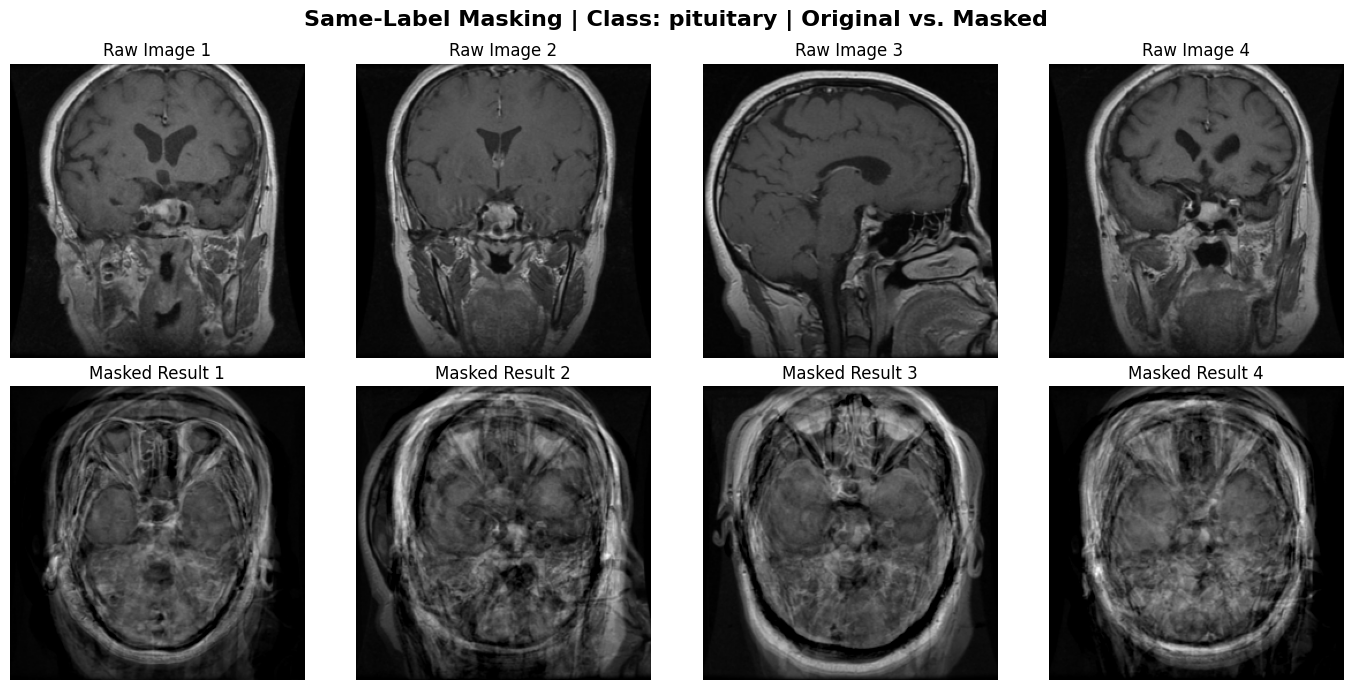

95

In [ ]:
import random
import matplotlib.pyplot as plt

print("\n=====================================================================")
print("VISUALIZING MATRIX MASKING ENCRYPTION (FIGSHARE MRI)")
print("=====================================================================")

# 1. Pick a random class from the dataset
unique_classes = np.unique(train_dataset_full.targets)
random_class = random.choice(unique_classes)
class_name = train_dataset_full.classes[random_class]

# 2. Grab 16 RANDOM images of that SAME class
class_indices = (np.array(train_dataset_full.targets) == random_class).nonzero()[0]
selected_indices = np.random.choice(class_indices, size=16, replace=False)

X_viz = torch.stack([train_dataset_full[i][0] for i in selected_indices]).to(device)
Y_viz = torch.stack([torch.tensor(train_dataset_full[i][1]) for i in selected_indices]).to(device)

# 3. Apply Same-Label Mask
A_viz = generate_row_mask_gpu(Y_viz, 16, device)
X_viz_masked = A_viz @ X_viz

# 4. Plotting Function
def unnormalize(tensor):
    return (tensor * 0.5) + 0.5

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle(f"Same-Label Masking | Class: {class_name} | Original vs. Masked", fontsize=16, fontweight='bold')

for i in range(4):
    # Original Image
    ax_orig = axes[0, i]
    img_orig = unnormalize(X_viz[i]).view(IMAGE_SIZE, IMAGE_SIZE).cpu().numpy()
    ax_orig.imshow(img_orig, cmap='gray', vmin=0, vmax=1)
    ax_orig.set_title(f"Raw Image {i+1}")
    ax_orig.axis('off')

    # Masked Image
    ax_mask = axes[1, i]
    img_mask = unnormalize(X_viz_masked[i]).view(IMAGE_SIZE, IMAGE_SIZE).cpu().numpy()
    ax_mask.imshow(img_mask, cmap='gray', vmin=0, vmax=1)
    ax_mask.set_title(f"Masked Result {i+1}")
    ax_mask.axis('off')

plt.tight_layout()
plt.show()

# Clean up memory
del X_viz, Y_viz, A_viz, X_viz_masked
torch.cuda.empty_cache()
gc.collect()

## 3. Model Architecture Definitions
To ensure complete transparency and allow researchers to build upon our work, we define the exact `DenseNet-121` architecture utilized. Because Figshare images are high-resolution (256x256), we keep the standard 7x7 stride-2 convolutions and pooling layers, only adapting the input channel from 3 (RGB) to 1 (Grayscale).

In [ ]:
import torchvision.models as models

# --- High-Resolution DenseNet-121 ---
def get_model(num_classes=4):
    model = models.densenet121(weights=None)
    # Adapt for 1-channel Grayscale. Since Figshare is 256x256,
    # we can keep the standard 7x7 stride 2 convolution and pooling layers
    model.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model.to(device)

## 4. Evaluation Code: Inference Batch Size Testing
Model evaluation on static masks depends heavily on inference configurations. The function below contains the exact procedure used to evaluate the model's performance on both Masked and Raw data for dynamically changing $N \times N$ chunks, heavily optimized to prevent VRAM explosion on large datasets. Executing this will populate the inference table in the results section.

In [ ]:
print("\n=====================================================================")
print("NEW TESTING METHOD: INFERENCE BATCH SIZE EVALUATION (MASKED VS RAW)")
print("=====================================================================")

# Instantiate the heavy DenseNet-121 model
cloud_cnn = get_model(num_classes=num_classes).to(device)

def evaluate_inference_size(model, test_dataset, N, device):
    """
    Evaluates the model's performance on both Masked and Raw data for an NxN chunk.
    Memory optimized for massive high-resolution arrays.
    """
    model.eval()
    loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)
    X_all, Y_all = next(iter(loader))
    Y_all = Y_all.squeeze()

    correct_masked = 0
    correct_raw = 0
    total = 0

    with torch.no_grad():
        for cls in torch.unique(Y_all):
            indices = (Y_all == cls).nonzero(as_tuple=True)[0]

            # Process in strict chunks of size N
            for i in range(0, len(indices), N):
                idx_chunk = indices[i:i+N]

                # We only evaluate exact N-sized chunks to properly test the N value
                if len(idx_chunk) == N:
                    X_chunk = X_all[idx_chunk].to(device)
                    Y_chunk = Y_all[idx_chunk].to(device)

                    # 1. Evaluate on Masked Data
                    A_mask = generate_row_mask_gpu(Y_chunk, N, device)
                    X_chunk_masked = torch.matmul(A_mask, X_chunk)

                    # CRITICAL FIX: Reshape before passing to model
                    x_masked_reshaped = X_chunk_masked.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE)
                    preds_masked = torch.argmax(model(x_masked_reshaped), dim=1)
                    correct_masked += (preds_masked == Y_chunk).sum().item()

                    # 2. Evaluate on Raw Data
                    # CRITICAL FIX: Reshape before passing to model
                    x_raw_reshaped = X_chunk.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE)
                    preds_raw = torch.argmax(model(x_raw_reshaped), dim=1)
                    correct_raw += (preds_raw == Y_chunk).sum().item()

                    total += N

                    # Clean up memory immediately to prevent DenseNet OOM
                    del X_chunk, Y_chunk, A_mask, X_chunk_masked, x_masked_reshaped, x_raw_reshaped, preds_masked, preds_raw
                    torch.cuda.empty_cache()

    acc_masked = correct_masked / total if total > 0 else 0
    acc_raw = correct_raw / total if total > 0 else 0

    return acc_masked, acc_raw


NEW TESTING METHOD: INFERENCE BATCH SIZE EVALUATION (MASKED VS RAW)


## 5. Training Code: Cloud Phase & Hospital Domain Adaptation
This section contains the core training scripts used to obtain the principal overhead and inference results stated in the paper. Running this cell directly outputs the exact metrics presented in our figures.

**Training Procedure & Figshare Transfer Logic:**
1. **Cloud Phase:** Heavy training on masked data using PyTorch Mixed Precision (`torch.amp.GradScaler`).
2. **Hospital Phase:** Simulates the local hospital unfreezing a minimal subset of weights: `BatchNorm` layers, `denseblock4`, `norm5`, and the final `classifier`.
3. **Inference Loop:** Iteratively tests the trained model against various inference batch sizes ($N=1, 5, 10...$) to map out privacy bounds.

In [ ]:
import os
# Prevent CUDA memory fragmentation
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import time
import copy
import gc
import math
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import models
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset, random_split

# --- HARDWARE ACCELERATION ---
# Auto-tunes convolutions for maximum hardware speed in Colab
torch.backends.cudnn.benchmark = True

# Force a deep clean of the GPU VRAM
gc.collect()
torch.cuda.empty_cache()

# =====================================================================
# 0. HELPER FUNCTION: VALIDATION EVALUATOR
# =====================================================================
def eval_model_loss_acc(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for X_b, Y_b in loader:
            X_b = X_b.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
            Y_b = Y_b.to(device)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(X_b)
                loss = criterion(outputs, Y_b)

            running_loss += loss.item() * X_b.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == Y_b).sum().item()
            total += Y_b.size(0)

            del X_b, Y_b, outputs, loss
    return running_loss / total, correct / total


# =====================================================================
# 1. SETUP: THE KNOWLEDGE POOL & VAULT
# =====================================================================
print("\n=====================================================================")
print("THE FINAL SCALPEL: SUPER-CONVERGENCE + VRAM OPTIMIZED")
print("=====================================================================")

# Cloud Split (80% Train / 20% Val)
num_cloud_train = len(train_masked_ds)
cloud_val_size = int(0.20 * num_cloud_train)
cloud_train_size = num_cloud_train - cloud_val_size

generator = torch.Generator().manual_seed(42)
cloud_train_sub, cloud_val_sub = random_split(train_masked_ds, [cloud_train_size, cloud_val_size], generator=generator)

# I/O OPTIMIZED: Colab specific pinning and workers
cloud_train_loader = DataLoader(cloud_train_sub, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
cloud_val_loader = DataLoader(cloud_val_sub, batch_size=TEST_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# THE VAULT
test_loader_masked = DataLoader(test_masked_ds, batch_size=TEST_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_raw = DataLoader(test_dataset_full, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Initialize Unified DenseNet-121
cloud_model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT, memory_efficient=True)
old_conv = cloud_model.features.conv0
cloud_model.features.conv0 = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                                       stride=old_conv.stride, padding=old_conv.padding, bias=old_conv.bias)
num_ftrs = cloud_model.classifier.in_features
cloud_model.classifier = nn.Linear(num_ftrs, 4)
cloud_model = cloud_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_cloud = optim.Adam(cloud_model.parameters(), lr=0.0001)


# =====================================================================
# 2. CLOUD PHASE: Heavy Training on Masked Data
# =====================================================================
CLOUD_MAX_EPOCHS = 200
patience = 40
min_delta = 0.001
epochs_no_improve = 0
best_cloud_loss = float('inf')
best_cloud_weights = None
cloud_epochs_run = 0

print(f"1. CLOUD PHASE: Training CNN on Masked Data...")

torch.cuda.reset_peak_memory_stats()
start_time_cloud = time.time()
scaler = torch.amp.GradScaler('cuda')

for epoch in range(1, CLOUD_MAX_EPOCHS + 1):
    cloud_epochs_run += 1
    cloud_model.train()

    for X_b, Y_b in cloud_train_loader:
        x_reshaped = X_b.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
        Y_b = Y_b.to(device)

        optimizer_cloud.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = cloud_model(x_reshaped)
            loss = criterion(outputs, Y_b)

        scaler.scale(loss).backward()
        scaler.step(optimizer_cloud)
        scaler.update()
        del X_b, Y_b, x_reshaped, outputs, loss

    val_loss, val_acc = eval_model_loss_acc(cloud_model, cloud_val_loader, criterion)

    print(f"   Epoch {epoch:>3} | Masked Val Loss: {val_loss:.4f} | Masked Acc: {val_acc:.4f} | Patience: {epochs_no_improve}/{patience}")

    if val_loss < (best_cloud_loss - min_delta):
        best_cloud_loss = val_loss
        best_cloud_weights = copy.deepcopy(cloud_model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"   -> Early Stopping Triggered! Restoring best Cloud weights.")
        break

if best_cloud_weights:
    cloud_model.load_state_dict(best_cloud_weights)

cloud_time = time.time() - start_time_cloud
cloud_memory = torch.cuda.max_memory_allocated() / (1024 ** 2)


# =====================================================================
# 2.5 CLOUD VAULT TEST: Baseline Performance
# =====================================================================
print("\n=====================================================================")
print("PRE-TRANSFER EVALUATION: CLOUD MODEL ON VAULT DATA")
print("=====================================================================")
cloud_vault_masked_loss, cloud_vault_masked_acc = eval_model_loss_acc(cloud_model, test_loader_masked, criterion)
cloud_vault_raw_loss, cloud_vault_raw_acc = eval_model_loss_acc(cloud_model, test_loader_raw, criterion)
print(f"[CLOUD VAULT BASELINE] Masked Acc: {cloud_vault_masked_acc:.4f} | Raw Acc: {cloud_vault_raw_acc:.4f}\n")


# =====================================================================
# 3. HOSPITAL PHASE: Super-Convergence (Time & VRAM Optimized)
# =====================================================================
print("3. HOSPITAL PHASE: Fast Tuning (OneCycleLR + Parallel Dataloading)...")

# --- STRATIFIED SAMPLING LOGIC (Maintains Balance) ---
num_full_raw = len(train_dataset_full)
num_local_images = int(num_full_raw * 1)
num_classes = 4
samples_per_class = num_local_images // num_classes

try:
    targets = np.array(train_dataset_full.targets)
except AttributeError:
    targets = np.array([y for _, y in train_dataset_full])

local_indices = []
np.random.seed(42)

for c in range(num_classes):
    class_idx = np.where(targets == c)[0]
    chosen = np.random.choice(class_idx, samples_per_class, replace=False)
    local_indices.extend(chosen)

local_indices = np.array(local_indices)
np.random.shuffle(local_indices)

local_raw_pool = Subset(train_dataset_full, local_indices)

num_hosp_train = len(local_raw_pool)
hosp_val_size = int(0.20 * num_hosp_train)
hosp_train_size = num_hosp_train - hosp_val_size

hosp_raw_train, hosp_raw_val = random_split(local_raw_pool, [hosp_train_size, hosp_val_size], generator=generator)

# VRAM REDUCTION (Gradient Accumulation Math)
TARGET_EFFECTIVE_BATCH = max(1, BATCH_SIZE // 4)
ACCUMULATION_STEPS = 4
MICRO_BATCH_SIZE = max(1, TARGET_EFFECTIVE_BATCH // ACCUMULATION_STEPS)

hosp_raw_loader = DataLoader(hosp_raw_train, batch_size=MICRO_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
hosp_val_loader = DataLoader(hosp_raw_val, batch_size=MICRO_BATCH_SIZE * 2, shuffle=False, num_workers=2, pin_memory=True)

hosp_augmentations = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=10, translate=(0.05, 0.05))
])

hospital_model = copy.deepcopy(cloud_model)

# 1. Freeze EVERYTHING first
for param in hospital_model.parameters():
    param.requires_grad = False

# 2. Unfreeze all BatchNorm layers
for module in hospital_model.modules():
    if isinstance(module, nn.BatchNorm2d):
        for param in module.parameters():
            param.requires_grad = True

# 3. Unfreeze denseblock4 and norm5
for param in hospital_model.features.denseblock4.parameters():
    param.requires_grad = True
for param in hospital_model.features.norm5.parameters():
    param.requires_grad = True

# 4. Unfreeze the final Classifier head
for param in hospital_model.classifier.parameters():
    param.requires_grad = True

params_to_update = [param for param in hospital_model.parameters() if param.requires_grad]

optimizer_hospital = torch.optim.Adam(params_to_update, lr=5e-5, weight_decay=1e-4)

# --- TIME OPTIMIZATION: ONE-CYCLE LR ---
HOSPITAL_MAX_EPOCHS = 50 # Extended slightly for a longer, smoother cooldown phase
total_optimizer_steps = math.ceil(len(hosp_raw_loader) / ACCUMULATION_STEPS)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer_hospital,
    max_lr=1e-4,
    epochs=HOSPITAL_MAX_EPOCHS,
    steps_per_epoch=total_optimizer_steps,
    pct_start=0.2, # 20% of time ramping up, 80% gliding down perfectly to zero
    div_factor=10.0,
    final_div_factor=1000.0
)

hosp_patience = 3
min_delta_hosp = 0.001
hosp_epochs_no_improve = 0
best_hosp_loss = float('inf')
best_hospital_weights = None
hospital_epochs_run = 0

torch.cuda.reset_peak_memory_stats()
start_time_hospital = time.time()

for epoch in range(1, HOSPITAL_MAX_EPOCHS + 1):
    hospital_epochs_run += 1
    hospital_model.train()
    optimizer_hospital.zero_grad(set_to_none=True)

    for i, (X_b, Y_b) in enumerate(hosp_raw_loader):
        X_b = X_b.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
        X_b = hosp_augmentations(X_b)
        Y_b = Y_b.to(device)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = hospital_model(X_b)
            loss = criterion(outputs, Y_b)
            loss = loss / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(hosp_raw_loader):
            scaler.unscale_(optimizer_hospital)
            torch.nn.utils.clip_grad_norm_(hospital_model.parameters(), max_norm=1.0)

            scaler.step(optimizer_hospital)
            scaler.update()

            scheduler.step()
            optimizer_hospital.zero_grad(set_to_none=True)

        del X_b, Y_b, outputs, loss

    raw_val_loss, raw_val_acc = eval_model_loss_acc(hospital_model, hosp_val_loader, criterion)
    _, masked_test_acc = eval_model_loss_acc(hospital_model, test_loader_masked, criterion)

    current_lr = optimizer_hospital.param_groups[0]['lr']

    print(f"   Epoch {epoch:>2}/{HOSPITAL_MAX_EPOCHS} | Raw Val Loss: {raw_val_loss:.4f} | Masked Acc: {masked_test_acc:.4f} | Raw Acc: {raw_val_acc:.4f} | LR: {current_lr:.1e} | Patience: {hosp_epochs_no_improve}/{hosp_patience}")

    if raw_val_loss < (best_hosp_loss - min_delta_hosp):
        best_hosp_loss = raw_val_loss
        best_hospital_weights = copy.deepcopy(hospital_model.state_dict())
        hosp_epochs_no_improve = 0
    else:
        hosp_epochs_no_improve += 1

    if hosp_epochs_no_improve >= hosp_patience:
        print(f"   -> Early Stopping Triggered! Restoring best Local weights.")
        break

if best_hospital_weights:
    hospital_model.load_state_dict(best_hospital_weights)

hospital_time = time.time() - start_time_hospital
hospital_memory = torch.cuda.max_memory_allocated() / (1024 ** 2)


# =====================================================================
# 4. OPENING THE VAULT: FINAL UNBIASED EVALUATION
# =====================================================================
print("\n=====================================================================")
print("POST-TRANSFER EVALUATION: HOSPITAL MODEL ON VAULT DATA")
print("=====================================================================")
print("\n--> TRANSFER LEARNING OVERHEAD COST:")
print(f"    Data Volume: Cloud used {cloud_train_size} train imgs | Hospital used {hosp_train_size} augmented raw imgs")
print(f"    Cloud Training Took: {cloud_epochs_run} epochs ({cloud_time:.2f} sec, {cloud_memory:.2f} MB)")
print(f"    Hospital Tuning Took: {hospital_epochs_run} epochs ({hospital_time:.2f} sec, {hospital_memory:.2f} MB)")

final_masked_loss, final_masked_acc = eval_model_loss_acc(hospital_model, test_loader_masked, criterion)
final_raw_loss, final_raw_acc = eval_model_loss_acc(hospital_model, test_loader_raw, criterion)

print(f"\n[HOSPITAL VAULT TEST] Final Masked Acc: {final_masked_acc:.4f} | Final Raw Acc: {final_raw_acc:.4f}\n")


# =====================================================================
# 5. POST-TUNING INFERENCE LOOP
# =====================================================================
print("4. Running Post-Tuning Inference Batch Size Loop on Calibrated Model...")

inference_batch_sizes = [1, 5, 10, 20, 30, 40, 50, 60, 64]

for n in inference_batch_sizes:
    temp_loader_masked = DataLoader(test_masked_ds, batch_size=n, shuffle=False, num_workers=2, pin_memory=True)
    temp_loader_raw = DataLoader(test_dataset_full, batch_size=n, shuffle=False, num_workers=2, pin_memory=True)

    _, acc_m = eval_model_loss_acc(hospital_model, temp_loader_masked, criterion)
    _, acc_r = eval_model_loss_acc(hospital_model, temp_loader_raw, criterion)

    print(f"   -> Inference N = {n:>4} | Masked Acc: {acc_m:.4f} | Raw Acc: {acc_r:.4f}")


THE FINAL SCALPEL: SUPER-CONVERGENCE + VRAM OPTIMIZED
1. CLOUD PHASE: Training CNN on Masked Data...
   Epoch   1 | Masked Val Loss: 1.6363 | Masked Acc: 0.2491 | Patience: 0/40
   Epoch   2 | Masked Val Loss: 1.4561 | Masked Acc: 0.2777 | Patience: 0/40
   Epoch   3 | Masked Val Loss: 1.2466 | Masked Acc: 0.2741 | Patience: 0/40
   Epoch   4 | Masked Val Loss: 0.9147 | Masked Acc: 0.4018 | Patience: 0/40
   Epoch   5 | Masked Val Loss: 0.6083 | Masked Acc: 0.7214 | Patience: 0/40
   Epoch   6 | Masked Val Loss: 0.4167 | Masked Acc: 0.8688 | Patience: 0/40
   Epoch   7 | Masked Val Loss: 0.2896 | Masked Acc: 0.9187 | Patience: 0/40
   Epoch   8 | Masked Val Loss: 0.1666 | Masked Acc: 0.9563 | Patience: 0/40
   Epoch   9 | Masked Val Loss: 0.0799 | Masked Acc: 0.9795 | Patience: 0/40
   Epoch  10 | Masked Val Loss: 0.0326 | Masked Acc: 0.9946 | Patience: 0/40
   Epoch  11 | Masked Val Loss: 0.0108 | Masked Acc: 0.9982 | Patience: 0/40
   Epoch  12 | Masked Val Loss: 0.0045 | Masked Acc